<a href="https://colab.research.google.com/github/lalawee/special-octo-barnacle/blob/main/2201360_bandit_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Multi-Armed Bandit Problem**
This classic RL problem demonstrates the
exploration–exploitation tradeoff dilemma.

Imagine a gambler at a row of slot
machines ("one-armed bandits") deciding
which ones to play, how many times to
play each one and in which order to play
them, and whether to continue with current machine or try different one.

In the problem, each slot machine provides a random reward from a probability distribution specific to that machine, that is not known a priori. The objective of the gambler is to maximize the sum of rewards earned through a sequence of lever pulls.

The crucial tradeoff the gambler faces at each trial is between "exploitation" of the machine that has the highest expected payoff calculated thus far and "exploration" to get more information about the expected payoffs of the other machines in the hope to get even better payoffs. This trade-off between exploration and exploitation is constantly faced in RL.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
#
# Define Constants
#
N_ARMS=10 #10 "bandits" in a row
N_STEPS = 10000 #10K steps
EPS = 0.1 #Epsilon

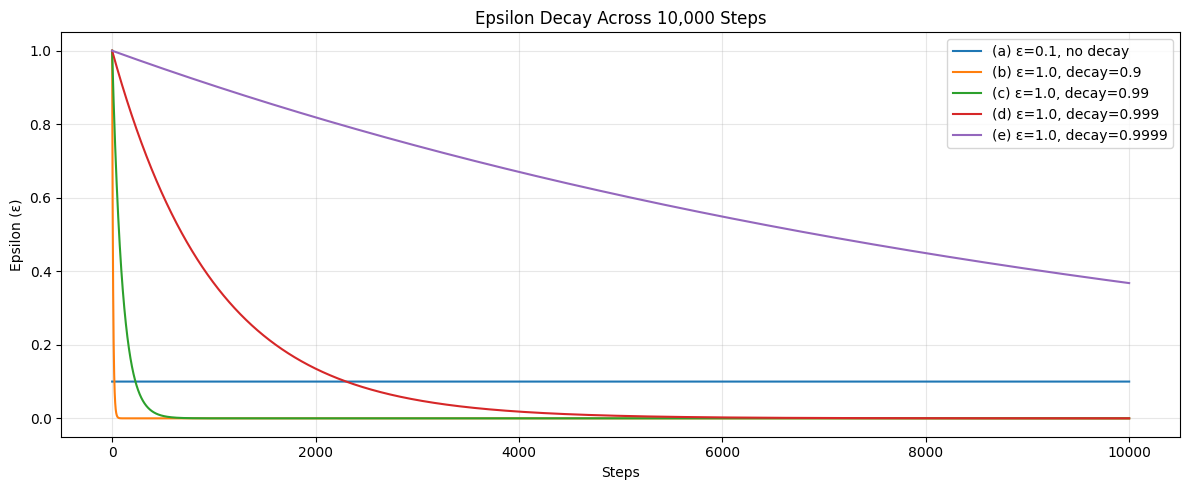

In [8]:


# TASK  1 to visualize the  relationship across 5 cases...

cases = [
    {"label": "a", "desc": "ε=0.1, no decay",    "eps0": 0.1, "decay": 1.0},
    {"label": "b", "desc": "ε=1.0, decay=0.9",   "eps0": 1.0, "decay": 0.9},
    {"label": "c", "desc": "ε=1.0, decay=0.99",  "eps0": 1.0, "decay": 0.99},
    {"label": "d", "desc": "ε=1.0, decay=0.999", "eps0": 1.0, "decay": 0.999},
    {"label": "e", "desc": "ε=1.0, decay=0.9999","eps0": 1.0, "decay": 0.9999},
]

plt.figure(figsize=(12, 5))

for case in cases:
    eps = case["eps0"]
    history = []
    for _ in range(N_STEPS):
        history.append(eps)
        eps *= case["decay"]
    plt.plot(history, label=f"({case['label']}) {case['desc']}")

plt.xlabel("Steps")
plt.ylabel("Epsilon (ε)")
plt.title("Epsilon Decay Across 10,000 Steps")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:
"""
Q: What can we say about (d) and (e) vs (b) and (c) in later steps?
Cases (b) and (c) decay so aggressively that ε → ~0 well before step 10,000 — the agent essentially stops exploring entirely and is locked into whatever arm it thinks is best.
 Cases (d) and (e) retain meaningful ε much longer,
so the agent still occasionally tries random arms even late in training. Case (e) (decay=0.9999) still has ε ≈ 0.37 at step 10,000!


Q: How would average total reward compare?
(d) and (e) should yield higher average total reward than (b) and (c), because:
(b) decays so fast (~100 steps) it may commit to a suboptimal arm before gathering enough data
Slow decay = more chances to discover the best arm (arm 9, p=0.9) before exploiting it
The tradeoff is that (e) might "waste" pulls on random arms late in training, but this is minor compared to the risk of being stuck on a bad arm forever
"""

In [ ]:
#
# Define the Multi-Armed Bandit class
# (1 row of N_ARMS slot machines)
#
class MultiArmedBandit:
    # Initializer
    def __init__(self):
       # probability distribution specific to the N_ARMS slot machine (not known before hand)
       self.probabilities=np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

    # Simulate a single pull of slot machine arm
    # returns a win 1 or lose 0
    def pull(self, arm):
        return 1 if np.random.rand() < self.probabilities[arm] else 0

In [ ]:
#
# Define the Agent using the Epsilon-Greedy strategy
#
class EpsilonGreedyAgent:
    # Initializer
    def __init__(self, epsilon):
        self.epsilon = epsilon
        self.est_returns = np.zeros(N_ARMS)  # Estimated expected returns for each arm
        self.arm_counts = np.zeros(N_ARMS)  # Number of times each arm was pulled
        self.total_rewards = np.zeros(N_ARMS) # Total rewards accumulated for each slot machine

    # Select an arm to pull based on the Epsilon-Greedy strategy
    def select_arm(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(N_ARMS)  # Explore: Return a random arm 0 to N_ARMS-1
        else:
            return np.argmax(self.est_returns)  # Exploit: Return the index of arm with best returns thus far

    # Update estimated expected returns of an arm
    # (reward is 1 or 0)
    def update(self, arm, reward):
        self.arm_counts[arm] += 1
        self.total_rewards[arm] += reward
        self.est_returns[arm] = self.total_rewards[arm] / self.arm_counts[arm]

In [ ]:
#
# Instantiate and initialize a bandit (with 10 arms) and an agent
#
bandits = MultiArmedBandit()
agent = EpsilonGreedyAgent(EPS)

**Run Simulation for 1 Episode**
<br>(each episode has 10,000 pulls)

In [ ]:
#
# Run 1 episode of the simulation with 10K pulls
#
for step in range(N_STEPS):
    arm = agent.select_arm() # select arm using Epsilon-Greedy strategy
    reward = bandits.pull(arm) # 1 or 0 (win or lose)
    agent.update(arm, reward) # update arm's est reward

In [ ]:
print(f"Rewards of Each Arm = {agent.total_rewards}")
print(f"Arm Counts = {agent.arm_counts}")
print(f"Est Returns = {agent.est_returns}")
print(f"Total rewards = {sum(agent.total_rewards)}")

Rewards of Each Arm = [0.000e+00 5.000e+00 2.600e+01 3.300e+01 6.500e+01 7.300e+01 4.900e+01
 6.300e+01 7.800e+01 8.115e+03]
Arm Counts = [ 123.   93.  108.  106.  151.  136.   87.  100.   92. 9004.]
Est Returns = [0.         0.05376344 0.24074074 0.31132075 0.43046358 0.53676471
 0.56321839 0.63       0.84782609 0.9012661 ]
Total rewards = 8507.0
